# 04 - Random Forest
## Explainable Machine Learning for Breast Cancer Risk Prediction

Notebook ini **mandiri** (bisa dijalankan sendiri tanpa bergantung ke notebook lain) dan berfokus khusus pada satu algoritma: **Random Forest**.

Alur: Load Data -> Preprocessing -> Training + Hyperparameter Tuning -> Evaluasi -> Explainable AI (SHAP) -> Simpan hasil metrik ke `results_rf.csv` untuk dibandingkan di `05_Model_Comparison.ipynb`.


## 1. Import Library

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Library dasar berhasil diimpor.')

from sklearn.ensemble import RandomForestClassifier
import shap


Library dasar berhasil diimpor.


## 2. Load Data & Preprocessing

In [2]:

df = pd.read_csv('data/breast-cancer.csv')
df = df.drop(columns=['id'])

le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])  # B=0, M=1
print('Mapping label:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=['diagnosis', 'diagnosis_encoded'])
y = df['diagnosis_encoded']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
df.head()


Mapping label: {'B': np.int64(0), 'M': np.int64(1)}
Train shape: (455, 30) | Test shape: (114, 30)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_encoded
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


## 3. Fungsi Bantu Evaluasi

In [3]:

def evaluate_model(model, X_te, y_te, model_name):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1-Score': f1_score(y_te, y_pred),
        'ROC-AUC': roc_auc_score(y_te, y_proba)
    }
    return metrics, y_pred, y_proba

def plot_confusion_and_roc(y_te, y_pred, y_proba, model_name, color='#3B7DD8'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    cm = confusion_matrix(y_te, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'], cbar=False)
    axes[0].set_title(f'Confusion Matrix - {model_name}', fontweight='bold')
    axes[0].set_xlabel('Prediksi')
    axes[0].set_ylabel('Aktual')

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    auc = roc_auc_score(y_te, y_proba)
    axes[1].plot(fpr, tpr, color=color, linewidth=2.2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Kurva ROC - {model_name}', fontweight='bold')
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    plt.show()


## 4. Training & Hyperparameter Tuning - Random Forest

Model berbasis pohon tidak memerlukan scaling fitur, sehingga kita gunakan `X_train` / `X_test` asli.


In [4]:

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 6, 10],
    'min_samples_leaf': [1, 2, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                        rf_param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

model = rf_grid.best_estimator_
print('Best Random Forest params:', rf_grid.best_params_)
print('Best CV ROC-AUC:', round(rf_grid.best_score_, 4))


Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV ROC-AUC: 0.9889


## 5. Evaluasi Model - Random Forest

In [5]:

metrics, y_pred, y_proba = evaluate_model(model, X_test, y_test, 'Random Forest')
metrics_df = pd.DataFrame([metrics]).set_index('Model').round(4)
metrics_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9649,1.0,0.9048,0.95,0.9942


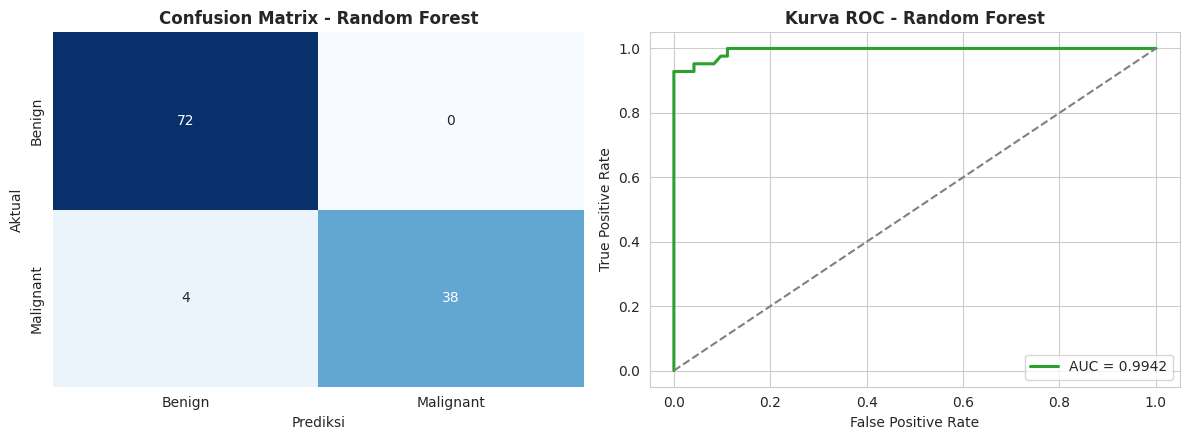

In [6]:

plot_confusion_and_roc(y_test, y_pred, y_proba, 'Random Forest', color='#2CA02C')


In [7]:

print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))


              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



## 6. Simpan Hasil Metrik (results_rf.csv)

In [8]:

metrics_df.to_csv('results_rf.csv')
print('Hasil metrik disimpan ke results_rf.csv')
metrics_df


Hasil metrik disimpan ke results_rf.csv

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9649,1.0,0.9048,0.95,0.9942


## 7. Explainable AI (XAI) - Random Forest

### 7.1 Feature Importance Bawaan Random Forest

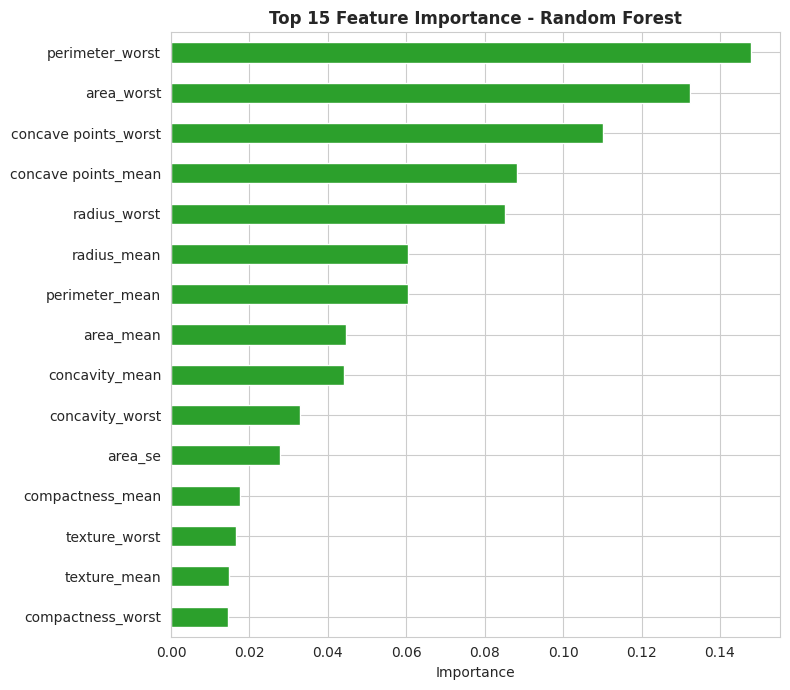

In [9]:

importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(8, 7))
importance.head(15).sort_values().plot(kind='barh', color='#2CA02C')
plt.title('Top 15 Feature Importance - Random Forest', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 7.2 SHAP Summary Plot

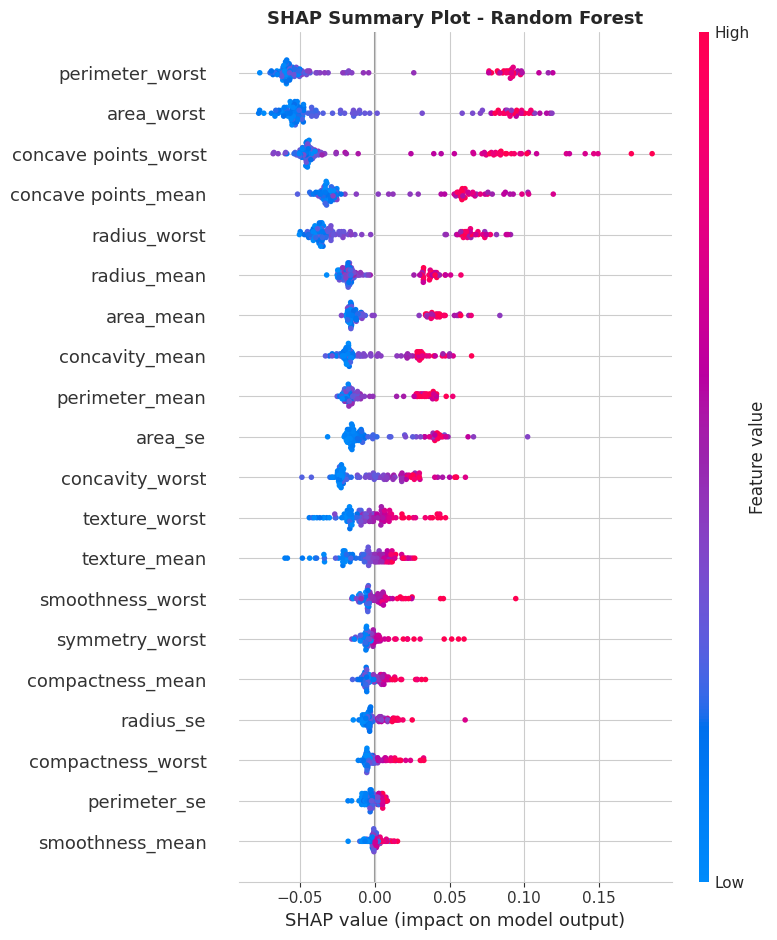

In [10]:

explainer = shap.TreeExplainer(model)
shap_values_raw = explainer.shap_values(X_test)

if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw[1]
elif shap_values_raw.ndim == 3:
    shap_values = shap_values_raw[:, :, 1]
else:
    shap_values = shap_values_raw

shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.3 SHAP Waterfall Plot - Interpretasi 1 Pasien

Prediksi: Benign | Aktual: Benign


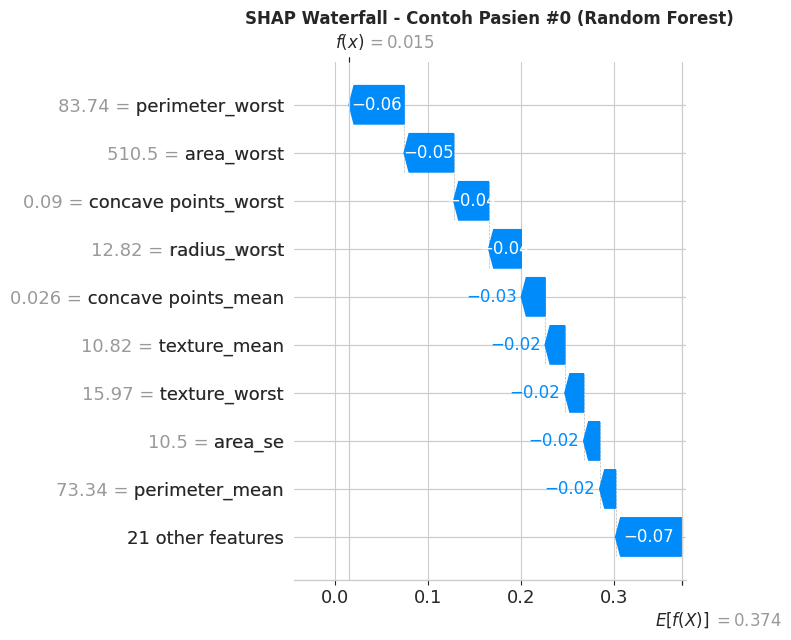

In [11]:

idx = 0
sample_pred = model.predict(X_test.iloc[[idx]])[0]
sample_actual = y_test.iloc[idx]
print(f"Prediksi: {'Malignant' if sample_pred==1 else 'Benign'} | Aktual: {'Malignant' if sample_actual==1 else 'Benign'}")

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1]

shap_explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=expected_value,
    data=X_test.iloc[idx],
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation, show=False)
plt.title(f'SHAP Waterfall - Contoh Pasien #{idx} (Random Forest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Kesimpulan Singkat - Random Forest

- Ringkasan metrik model ini tersimpan di `results_rf.csv` dan akan digabungkan dengan hasil model lain di `05_Model_Comparison.ipynb`.
- Model beserta parameter terbaik hasil `GridSearchCV` ditampilkan pada bagian training di atas.
- Interpretasi SHAP menunjukkan fitur-fitur mana yang paling berkontribusi terhadap prediksi model ini.
